Modern deep learning frameworks abstract away the mechanics of training. In the previous notebook I created a LinearLayer and ReLU which I am going to reuse.

This is part of a series of notebooks that show how Neural Networks actually work. In this notebook I will show and implement softmax activation and cross-entropy loss function. I will use them to classify the Iris dataset.

While this notebook focuses more on the math in the next one I will create a proper model wrapper.

The focus here is on understanding the forward and backward mechanics, not on model generalization or evaluation on held-out data.

**Dataset**

We are going to be working with a solved problem - classifying the Iris dataset. The point is to make sure our model logic works, and to verify it on a well-understood dataset with known outcomes.

[The iris dataset](https://www.kaggle.com/datasets/uciml/iris) was used in R.A. Fisher's classic 1936 paper, The Use of Multiple Measurements in Taxonomic Problems, and can also be found on the UCI Machine Learning Repository.

It includes three iris species with 50 samples each as well as some properties about each flower. One flower species is linearly separable from the other two, but the other two are not linearly separable from each other.

# Importing libraries

In [1]:
# importing libraries
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Helper functions and classes

In [2]:
# --- Colab setup (ignore if running locally) ---
if not Path("/content/ml-from-scratch").exists():
  !git clone https://github.com/vmirchev/ml-from-scratch.git

Cloning into 'ml-from-scratch'...
remote: Enumerating objects: 28, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 28 (delta 6), reused 26 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (28/28), 160.52 KiB | 5.54 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [3]:
import sys

# --- Colab setup (ignore if running locally) ---
# add the project root to the system path if not already present
project_root = Path("/content/ml-from-scratch")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.layers import LinearLayer
from src.activations import ReLU
from src.utils import set_seeds

In [4]:
# set seeds for reproducibility
seed = 42
set_seeds(seed)

In [5]:
def plot_training_curves(train_losses, train_accuracies):
  plt.figure(figsize=(14, 6))

  # plot for Loss
  plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
  plt.plot(train_losses, label='Train Loss')

  plt.title('Loss Over Epochs')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid(True)

  # plot for Accuracy
  plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
  plt.plot(train_accuracies, label='Train Accuracy')

  plt.title('Accuracy Over Epochs')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.grid(True)
  plt.tight_layout()
  plt.show()

# Loading the IRIS Dataset

In [6]:
candidate_paths = [
    Path("ml-from-scratch") / "data" / "iris_with_targets.csv",
    Path("data") / "iris_with_targets.csv",
]

csv_path = next((p for p in candidate_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("Could not find iris_with_targets.csv")

iris_df = pd.read_csv(csv_path)
print(f"Successfully loaded '{csv_path}' into a pandas DataFrame.")
iris_df.head()

Successfully loaded 'ml-from-scratch/data/iris_with_targets.csv' into a pandas DataFrame.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [7]:
feature_columns = iris_df.columns[:4]
target_column = iris_df.columns[4]
target_name_column = iris_df.columns[5]

features = iris_df[feature_columns].to_numpy(dtype=np.float32)
targets = iris_df[target_column].to_numpy(dtype=np.int64)
target_names_map = dict(iris_df[[target_column, target_name_column]].drop_duplicates().values)

print("Features shape:", features.shape)
print("Targets shape:", targets.shape)

Features shape: (150, 4)
Targets shape: (150,)


# Z-Score Normalization

When working with Neural Networks it is really useful to normalize data before forwarding it through the model. There are two most common ways of normalizing data - Z-Score normalization and Min-Max scaling. I will focus on the first.

The formula is pretty easy:

$$ z = \frac{x - \mu}{\sigma} $$

Ofcourse there is a small chance that the standard deviation may be 0, when all values are identical. To make the implementation more robust, I will still add a tiny epsilon in the denominator.

For simplicity, I normalize the full dataset here. In a real train/validation/test setup, normalization should be fit on the training data only.

In [8]:
class ZScoreNormalization:
  EPSILON = 1e-8

  def fit(self, x):
    self.mean = x.mean(axis=0)
    self.std = x.std(axis=0)

  def transform(self, x):
    if not hasattr(self, "mean") or not hasattr(self, "std"):
      raise ValueError("ZScoreNormalization must be fit before calling transform.")

    return (x - self.mean) / (self.std + self.EPSILON) # to account for zero std

  def fit_transform(self, x):
      self.fit(x)
      return self.transform(x)

Since this notebook only evaluates on the training data, I normalize the full dataset for simplicity. In a real train/validation/test setup, normalization must be fit on the training split only. In the next notebook I will show a proper train test split.

In [9]:
data_normalization = ZScoreNormalization()
normalized_features = data_normalization.fit_transform(features)

# features after standardization should have a standard deviation of 1.0
print("Original feature std per column:", features.std(axis=0))
print("Normalized feature std per column:", normalized_features.std(axis=0))
print("Normalized feature mean per column:", normalized_features.mean(axis=0))

assert np.allclose(normalized_features.mean(axis=0), 0.0, atol=1e-6)
assert np.allclose(normalized_features.std(axis=0), 1.0, atol=1e-6)

Original feature std per column: [0.8253013 0.434411  1.7594041 0.7596926]
Normalized feature std per column: [1.        0.9999999 1.        1.0000001]
Normalized feature mean per column: [ 1.0172526e-07 -3.1789145e-07 -1.0172526e-07  2.5431316e-08]


# Softmax activation function

To perform multi-class classification, the model outputs raw scores called logits. Softmax converts these logits into a probability distribution over classes.

In theory a softmax should help turn the raw logits, which may be negative numbers into probabilities between 0 and 1. To do that we use a softmax activation function.

The formula is pretty straightforward.

$$\sigma (\mathbf{z})_{i}=\frac{e^{z_{i}}}{\sum _{j=1}^{K}e^{z_{j}}}\quad \text{for }i=1,\dots ,K$$

But the softmax function relies on the natural exponent. Being a developer myself I can think of an issue. np.exp(x) can become so big, it can become bigger than max float.



In [10]:
# float64 limitation demo
print(np.exp(709))   # ≈ 8.2e307 (still OK)
print(np.exp(710))   # → inf (overflow)

8.218407461554972e+307
inf


/tmp/ipykernel_7974/3045391815.py:3: RuntimeWarning: overflow encountered in exp
  print(np.exp(710))   # → inf (overflow)


A common solution is to subtract the maximum logit from each row before exponentiating. This does not change the output probabilities, because softmax is invariant to adding or subtracting the same constant from all logits in a sample. It only improves numerical stability.

When working with batches, I need to account for the fact that operations are performed within each batch rather than across all values. Therefore, when calculating the softmax in the following cell both the maximum and the sum should be computed using axis=1.

In [11]:
def softmax(x):
  x = np.asarray(x, dtype=np.float64)
  if x.ndim == 1:
    x = x.reshape(1, -1)

  shifted_logits = x - np.max(x, axis=1, keepdims=True)
  exp_logits = np.exp(shifted_logits)
  return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

yHat = [-3, 11, 5, 0]
naive_softmax = np.exp(yHat) / np.sum(np.exp(yHat))
softmax_results = softmax(yHat)

# we have turned raw numbers into probabilities
print(f"Simple Softmax results: {naive_softmax}")

# should be 1.0 or really close to 1.0
print(f"Sum: {np.sum(naive_softmax):.3f}")

print("\n")

# should get the same values but in a batch of 1
print(f"Softmax results {softmax_results}")
print(f"Sum: {np.sum(softmax_results):.3f}")

Simple Softmax results: [8.29458155e-07 9.97509931e-01 2.47257991e-03 1.66601124e-05]
Sum: 1.000


Softmax results [[8.29458155e-07 9.97509931e-01 2.47257991e-03 1.66601124e-05]]
Sum: 1.000


# Cross-Entropy loss
So far I have only used Mean Squared Error for calculating the loss. But when working with classification problems Cross-Entropy loss is the right solution. For that to work, we need to convert logits into probabilities using the already defined softmax function.



## One-hot encoding
In this implementation, I use one-hot encoded vectors so they can be multiplied directly with the predicted class probabilities inside the cross-entropy formula.

The way to do that is pretty straight forward - convert the integer class labels (in this case [0,1,2]) into one-hot vectors ([1,0,0], [0,1,0], [0,0,1]) so each label becomes a target vector over classes, which can then be compared with predicted probabilities using cross-entropy loss.

In [12]:
num_classes = 3 # only for this toy example

y = [0, 1, 2]

def one_hot_encode(x, num_classes: int):
  x = np.asarray(x, dtype=int)
  if x.ndim != 1:
      raise ValueError("Input labels must be a 1D array.")
  if np.any(x < 0) or np.any(x >= num_classes):
      raise ValueError("Labels out of range for one-hot encoding.")
  return np.eye(num_classes, dtype=np.float32)[x]

# just like that we have encoded the raw targets into one-hot target vectors
one_hot_encoded_y = one_hot_encode(y, num_classes)
one_hot_encoded_y

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]], dtype=float32)

After being able to convert targets into one-hot-encoded probabilities, and defined the softmax activation functions we are ready to build the cross entropy loss.

Cross-entropy loss measures the performance of a classification model by calculating the difference between predicted probability distributions and actual labels.

$$ L = -\sum_{j} y_j \log(\hat{y}_j) $$

where ($y$) are the one-hot-encoded targets and $(\hat{y})$ is the model predictions after the softmax activation function is applied.



In [13]:
class CrossEntropyLoss:
  EPSILON = 1e-9

  def __init__(self):
    self.y_true = None
    self.softmax_output = None
    self.batch_size = 0

  def forward(self, logits, y_true):
    if logits.shape != y_true.shape:
      raise ValueError(f"logits shape {logits.shape} must match y_true shape {y_true.shape}")

    self.y_true = y_true
    self.batch_size = y_true.shape[0]

    # apply stable softmax
    self.softmax_output = softmax(logits)

    # clip probabilities for numerical stability - avoid log(0)
    clipped_softmax_output = np.clip(self.softmax_output, self.EPSILON, 1.0 - self.EPSILON)

    # calculate cross-entropy loss
    loss = -np.mean(np.sum(self.y_true * np.log(clipped_softmax_output), axis=1))
    return loss

  def backward(self):
    # dL/d(logits) = (softmax_output - y_true) / batch_size
    grad_logits = (self.softmax_output - self.y_true) / self.batch_size
    return grad_logits

# Creating mini batches
Using the full dataset as a batch would average gradients over all 150 samples, which can make updates smaller and less noisy. In practice, this often motivates a different learning rate choice and is one reason why mini-batch training is usually more practical.

For that reason I define a helper function to split the data into smaller batches and test it with sample data. Also important note is that the noise introduced by small mini-batches can also act as a mild regularizer and may help reduce overfitting in some settings.

In [14]:
def create_batches(X, y, batch_size=32, shuffle=True):
  if batch_size <= 0:
    raise ValueError("batch_size must be > 0")
  if len(X) != len(y):
    raise ValueError("X and y must have the same number of samples")

  num_samples = X.shape[0]
  if shuffle:
    # shuffle the indices
    indices = np.arange(num_samples)
    np.random.shuffle(indices)
    X = X[indices]
    y = y[indices]

  for i in range(0, num_samples, batch_size):
    yield X[i:i + batch_size], y[i:i + batch_size]

# Training a model

And now for the fun part. In the following cell, I build and train a simple model. The goal is not to demonstrate proper generalization - since we are not yet using validation or test sets, the model will likely overfit. Instead, the objective is to verify that learning is actually happening and to check whether the model can outperform a simple baseline of 33% (random chance).

In [15]:
set_seeds(seed)

ll1 = LinearLayer(in_features=4, out_features=16)
relu1 = ReLU()
ll2 = LinearLayer(in_features=16, out_features=16)
relu2 = ReLU()
ll3 = LinearLayer(in_features=16, out_features=3)

layers = [ll1, relu1, ll2, relu2, ll3]
trainable_layers = [ll1, ll2, ll3]

loss_fn = CrossEntropyLoss()

epochs = 1500  # intentionally high to show memorization on a tiny dataset
batch_size = 16
lr = 0.05
num_classes = len(np.unique(targets))

losses = []
accuracies = []

# intentionally training on the full dataset for mechanics demonstration only
for epoch in range(epochs):

  epoch_loss_sum = 0
  epoch_correct = 0
  epoch_total = 0

  for X_batch, y_batch in create_batches(normalized_features, targets, batch_size):

    y_true_one_hot = one_hot_encode(y_batch, num_classes=num_classes) # renamed for clarity

    # forward pass
    x = X_batch

    for layer in layers:
      x = layer.forward(x)

    logits = x

    # calculate the loss
    batch_loss = loss_fn.forward(logits, y_true_one_hot)
    epoch_loss_sum += batch_loss * len(y_batch)

    # calculate accuracy
    predictions = np.argmax(loss_fn.softmax_output, axis=1)
    epoch_correct += np.sum(predictions == y_batch)

    # update total count
    epoch_total += len(y_batch)

    # derivative of loss fn
    grad = loss_fn.backward()

    # gradient descent
    for layer in reversed(layers):
      grad = layer.backward(grad)

    # improved in next notebook with a model wrapper
    for layer in trainable_layers:
      layer.step(lr)

  epoch_loss = epoch_loss_sum / epoch_total
  epoch_accuracy = epoch_correct / epoch_total
  if epoch % 100 == 0:
    print(f"Epoch {epoch:4d} | loss: {epoch_loss:.4f} accuracy: {epoch_accuracy:.4f}")

  losses.append(epoch_loss)
  accuracies.append(epoch_accuracy)

Epoch    0 | loss: 1.4933 accuracy: 0.2667
Epoch  100 | loss: 0.0458 accuracy: 0.9867
Epoch  200 | loss: 0.0425 accuracy: 0.9867
Epoch  300 | loss: 0.0338 accuracy: 0.9867
Epoch  400 | loss: 0.0302 accuracy: 0.9867
Epoch  500 | loss: 0.0239 accuracy: 0.9867
Epoch  600 | loss: 0.0182 accuracy: 0.9933
Epoch  700 | loss: 0.0117 accuracy: 0.9933
Epoch  800 | loss: 0.0078 accuracy: 1.0000
Epoch  900 | loss: 0.0055 accuracy: 1.0000
Epoch 1000 | loss: 0.0039 accuracy: 1.0000
Epoch 1100 | loss: 0.0031 accuracy: 1.0000
Epoch 1200 | loss: 0.0023 accuracy: 1.0000
Epoch 1300 | loss: 0.0019 accuracy: 1.0000
Epoch 1400 | loss: 0.0016 accuracy: 1.0000


# Training results
To better visualize if the training is happening as expected I have created a function to plot losses and accuracies. This model overfits to the training data. Overfitting and underfitting are going to be one of the topics in the next notebook.

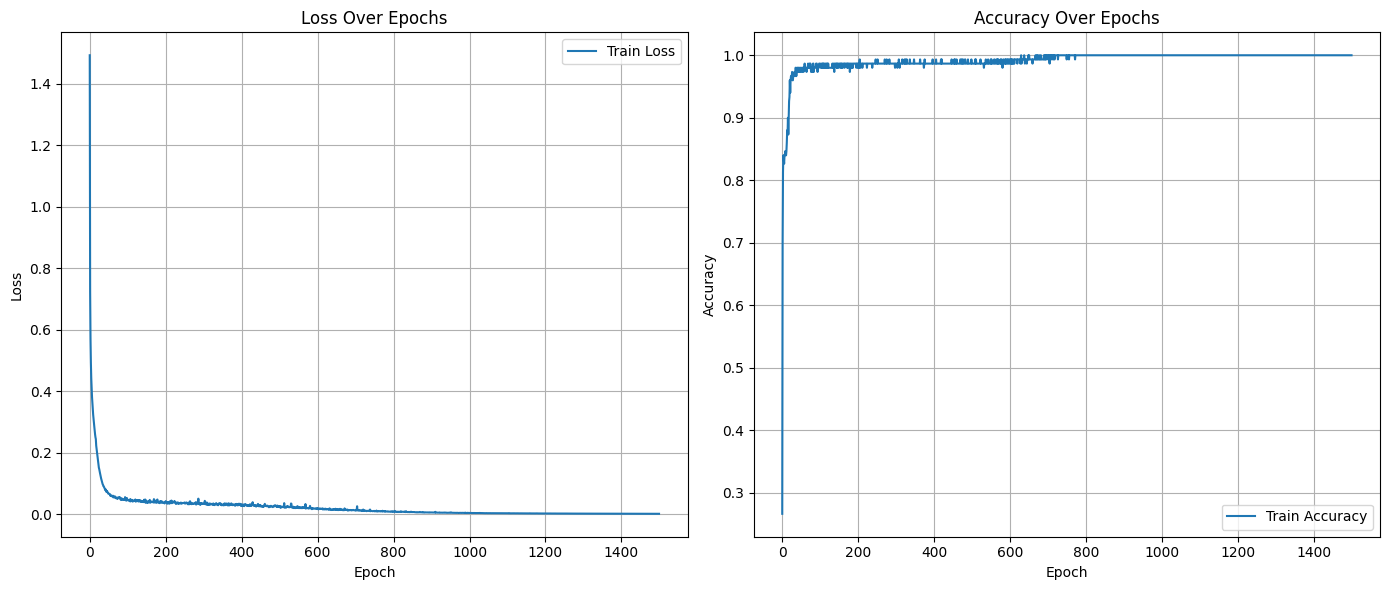

Best train accuracy: 1.0000
Lowest train loss: 0.0013


In [16]:
plot_training_curves(losses, accuracies)

print(f"Best train accuracy: {max(accuracies):.4f}")
print(f"Lowest train loss: {min(losses):.4f}")

# Make single prediction

I will pick a single random sample from the same dataset and check if the prediction is the same as the ground truth.

The point is to verify that the trained model produces a sensible prediction on a sample from the training distribution.

In [17]:
# run a random item
random_index = np.random.randint(len(normalized_features))
single_sample_batch = normalized_features[random_index].reshape(1, -1)
sample_target = targets[random_index]

x = single_sample_batch
for layer in layers:
  x = layer.forward(x)
logits = x

probs = softmax(logits)
predictions = np.argmax(probs, axis=1)

print("Predicted class index:", predictions[0])
print("Predicted class name:", target_names_map[predictions[0]])
print("Ground truth class index:", sample_target)
print("Ground truth class name:", target_names_map[sample_target])
print("Class probabilities:", probs[0])

Predicted class index: 1
Predicted class name: versicolor
Ground truth class index: 1
Ground truth class name: versicolor
Class probabilities: [0.00177409 0.9825914  0.01563452]


In [18]:
print(f"Final train loss: {losses[-1]:.4f}")
print(f"Final train accuracy: {accuracies[-1]:.4f}")
print(f"Best train accuracy: {max(accuracies):.4f}")
print("Chance level accuracy: 0.3333")

Final train loss: 0.0013
Final train accuracy: 1.0000
Best train accuracy: 1.0000
Chance level accuracy: 0.3333


The model fits the training data extremely well. Since I am not yet using a validation or test split in this notebook, I cannot properly measure generalization, but the setup makes overfitting likely.

In the next notebook, I will add a train/validation split and evaluate generalization more properly.